In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [2]:
file = h5py.File("/Volumes/SSD/data/hlca_50pc_50k.hdf5")
adata = sc.read_h5ad("/Volumes/SSD/data/hlca.h5ad", 'r')

In [26]:
dist = np.zeros_like(file["trajectory"]["0"])

In [27]:
for i in range(21):
    dist += np.abs(np.array(file["trajectory"][f"{i}"]))

In [49]:
df = pd.DataFrame({
    "dist": list(dist),
    "cell_type": adata.obs["cell_type"],
    "disease": adata.obs["disease"],
    "dev_stage": adata.obs["development_stage"]
})

In [50]:
dist_by_cell = df.groupby("cell_type", as_index=False)["dist"].mean()
dist_by_disease = df.groupby("disease", as_index=False)["dist"].mean()
dist_by_dev = df.groupby("dev_stage", as_index=False)["dist"].mean()

In [51]:
markers_by_cell = dist_by_cell["dist"].apply(lambda x: np.argsort(np.argsort(x)))
markers_by_disease = dist_by_disease["dist"].apply(lambda x: np.argsort(np.argsort(x)))
markers_by_dev = dist_by_dev["dist"].apply(lambda x: np.argsort(np.argsort(x)))

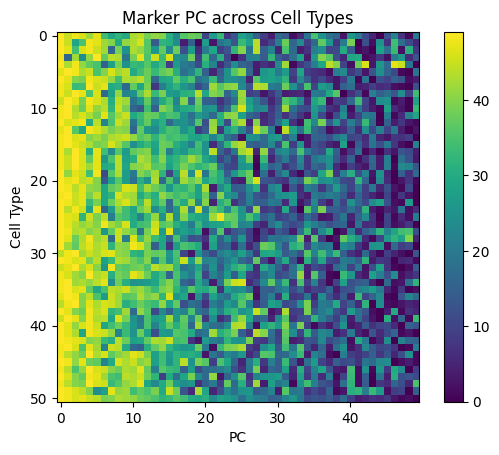

In [ ]:
plt.imshow(np.stack(markers_by_cell.values))
plt.colorbar()
plt.xlabel("PC")
plt.ylabel("Cell Type")
plt.title("Marker PC across Cell Types")
plt.show()

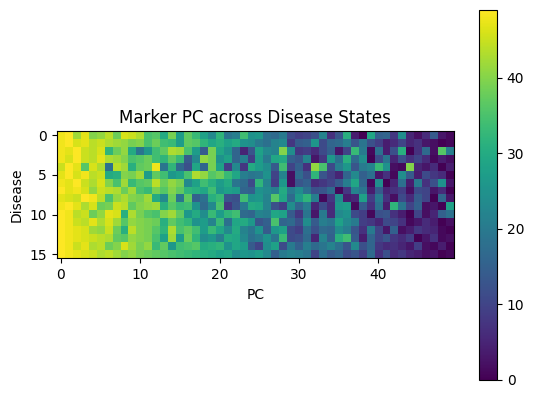

In [47]:
plt.imshow(np.stack(markers_by_disease.values))
plt.colorbar()
plt.xlabel("PC")
plt.ylabel("Disease")
plt.title("Marker PC across Disease States")
plt.show()

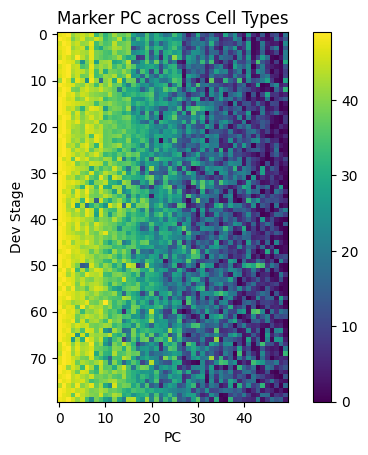

In [52]:
plt.imshow(np.stack(markers_by_dev.values))
plt.colorbar()
plt.xlabel("PC")
plt.ylabel("Dev Stage")
plt.title("Marker PC across Cell Types")
plt.show()

In [55]:
sc.tl.rank_genes_groups(adata, groupby='cell_type')

NotImplementedError: rank_genes_groups is not implemented for matrices of type <class 'anndata._core.sparse_dataset._CSRDataset'>

/var/folders/kw/c3pr6h9d7yd2y0dbhl8y5hgc0000gn/T/ipykernel_2659/3446409473.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis").copy()  # Use whichever colormap you prefer


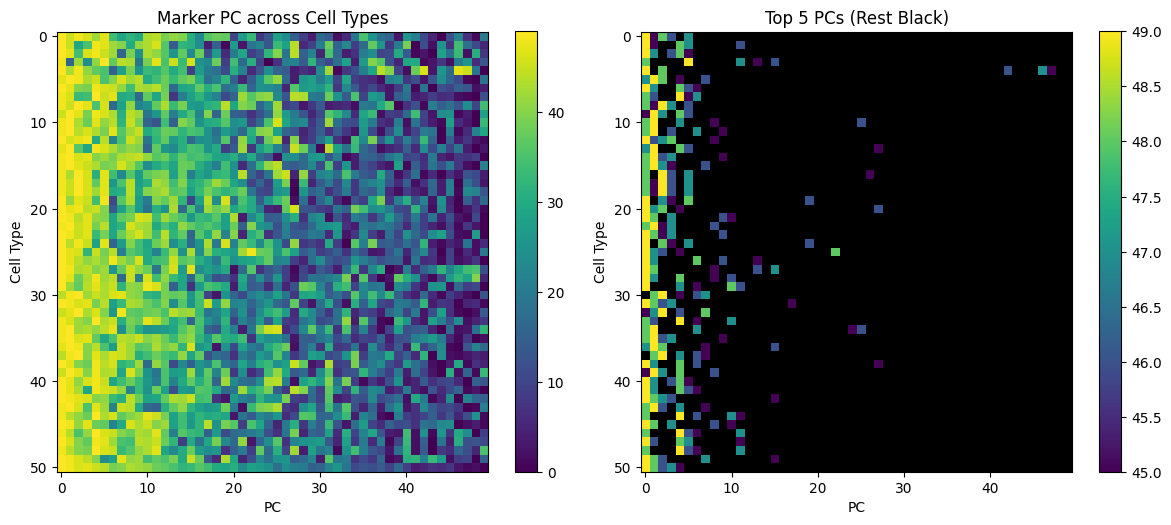

In [56]:
import matplotlib.cm as cm

# Get the stacked array
stacked = np.stack(markers_by_cell.values)

# Set up the figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: All Ranks ---
im1 = ax1.imshow(stacked)
fig.colorbar(im1, ax=ax1)
ax1.set_xlabel("PC")
ax1.set_ylabel("Cell Type")
ax1.set_title("Marker PC across Cell Types")

# --- Plot 2: Top 5 in color, rest black ---
# Find the threshold for the top 5 ranks. 
# (If you wanted the 5 smallest distances instead, change this to: masked_stacked = np.where(stacked < 5, stacked, np.nan))
threshold = stacked.shape[1] - 5
masked_stacked = np.where(stacked >= threshold, stacked, np.nan)

# Create a colormap and set NaN values to black
cmap = cm.get_cmap("viridis").copy()  # Use whichever colormap you prefer
cmap.set_bad("black")

im2 = ax2.imshow(masked_stacked, cmap=cmap)
fig.colorbar(im2, ax=ax2)
ax2.set_xlabel("PC")
ax2.set_ylabel("Cell Type")
ax2.set_title("Top 5 PCs (Rest Black)")

plt.tight_layout()
plt.show()